In [1]:
import jax
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
import jax
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [3]:
from cmap.clqt_jax import CLQT 
from linear_model_wv_data import make_wv_data
from cmap.linear_estimation_problem import Estimation 
from cmap.convert_est_clqt import est_to_clqt
from cmap.con_to_dis import f_convert


In [4]:
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parFwdBwdPass
from cmap.clqt_jax import combine_seqFwdBwdPass
from cmap.clqt_jax import seqFwdBwdPass

In [5]:
T = 1.0
q = 4.0
v = 1e-2
p0 = 0.001

t0=0.0

W = lambda t: q * jnp.eye(2)
H  = lambda t: jnp.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
R  = lambda t: v * jnp.eye(2)
P0 = p0 * jnp.eye(4)

F = lambda t: jnp.array(
        [
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0],
        ])

L = lambda t: jnp.array([[0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
Q = lambda t: L(t) @ W(t) @ L(t).T

c = lambda t: jnp.zeros((4,))
r = lambda t: jnp.zeros((2,))
m0 = jnp.array([5.0, 5.0, 0.0, 0.0])


In [6]:
def accuracy_test_linear_wv(steps,blocks,steps_all,T,kappa=200):

    

    b_init_m=jnp.zeros_like(m0)
    A_init_m=jnp.zeros_like(P0)
    C_init_m=kappa*jnp.eye(P0.shape[0])

    steps_all=steps*blocks
    
    dt=T/steps_all
    
    X, y_discrete, _ = make_wv_data(m0, P0, F(0), L(0), H(0), steps_all, dt, q, v, t0, seed=123)
    
    est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)
    
    F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
    clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)
    
    
     
    T=clqt.T
    dt = clqt.T / steps / blocks
    ST=clqt.ST
    vT=clqt.vT
    


    S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT,diffeq_solver='euler')
    


    A_seq,b_seq,C_seq=seqFwdBwdPass(clqt,steps*blocks,dt,t0,A_init_m,b_init_m,C_init_m,diffeq_solver='euler')
    _,x_fwdbwd_seq=combine_seqFwdBwdPass(S_seq, Kx_seq, v_seq, d_seq, A_seq, b_seq, C_seq)

    Kx_par_acc, d_par_acc, S_par_acc, v_par_acc = parBackwardPass(clqt, blocks, steps, t0, dt,diffeq_solver='euler')
    u_par_fb_acc,x_par_fb_acc = parFwdBwdPass(clqt, kappa,Kx_par_acc, d_par_acc, S_par_acc, v_par_acc, blocks, steps, dt, t0,diffeq_solver='euler')

    f, (ax1) = plt.subplots(1,1, figsize=(7,7))

    ax1.plot(x_par_fb_acc[:,0], x_par_fb_acc[:,1])
    ax1.plot(x_fwdbwd_seq[:,0],x_fwdbwd_seq[:,1])

    relative_error = (
    jnp.linalg.norm(x_fwdbwd_seq - x_par_fb_acc)
    / jnp.linalg.norm(x_fwdbwd_seq)
    )

    print(relative_error)

    return relative_error

 

Variant number of blocks sizes

In [7]:
kappa=1000

In [8]:
steps_all=5000000

In [9]:
blocks=steps_all//5
steps=steps_all//blocks
print(blocks,steps,steps_all)

1000000 5 5000000


6.749595006568577e-06


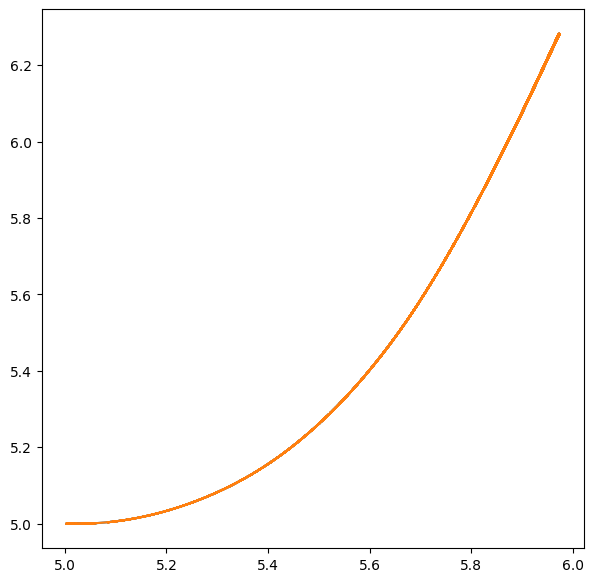

In [10]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T,kappa)

In [11]:
blocks=steps_all//10
steps=steps_all//blocks
print(blocks,steps,steps_all)

500000 10 5000000


6.7495971140888665e-06


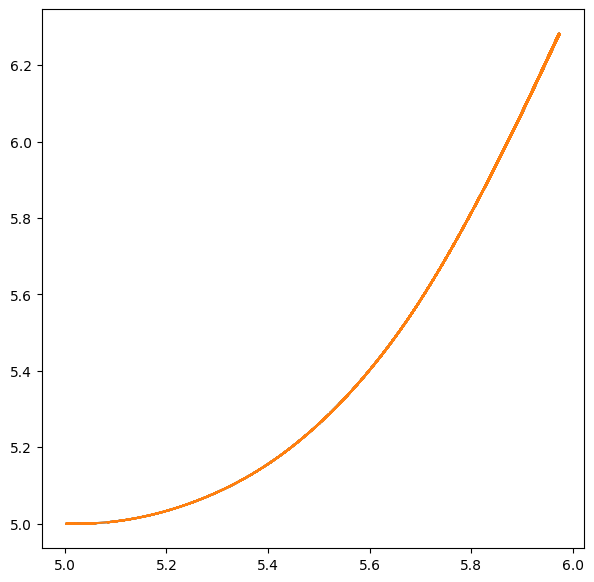

In [12]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T,kappa=1000)

In [13]:
blocks=steps_all//100
steps=steps_all//blocks
print(blocks,steps,steps_all,kappa)

50000 100 5000000 1000


6.749403571042399e-06


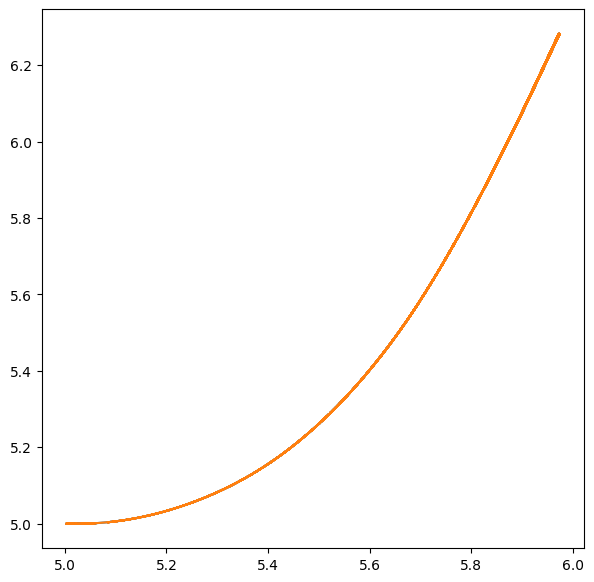

In [14]:
relative_error = accuracy_test_linear_wv(steps, blocks,steps_all,T,kappa)

In [15]:
blocks=steps_all//1000
steps=steps_all//blocks
print(blocks,steps,steps_all)

5000 1000 5000000


6.74768276333367e-06


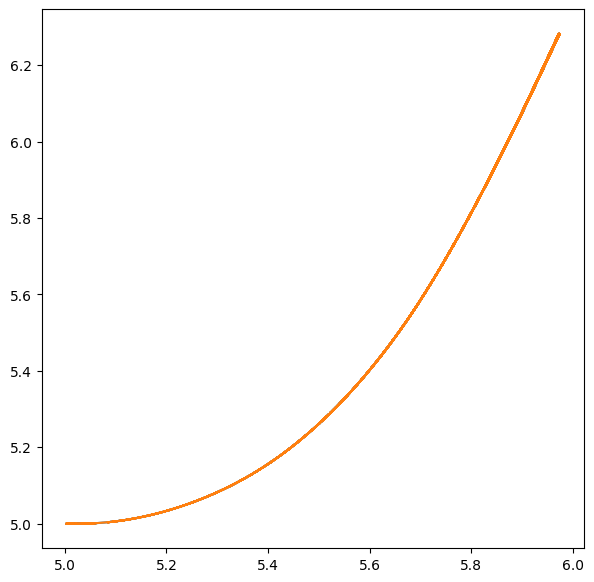

In [16]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T,kappa)

In [17]:
blocks=steps_all//10000
steps=steps_all//blocks
print(blocks,steps,steps_all)

500 10000 5000000


6.721813154553903e-06


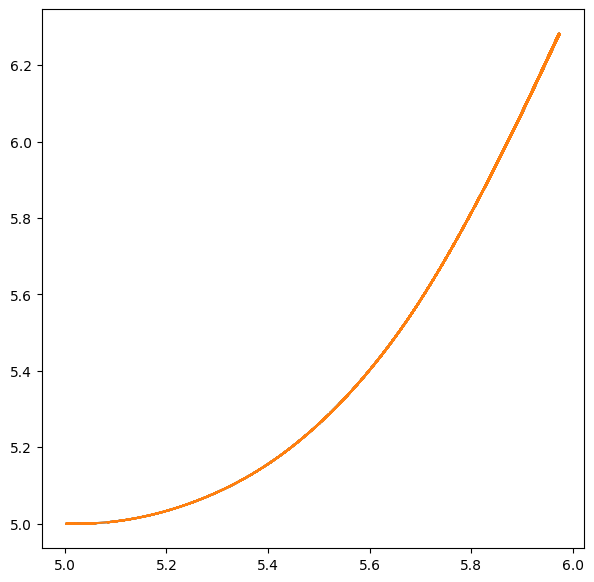

In [18]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T,kappa)

In [19]:
blocks=steps_all//100000
steps=steps_all//blocks
print(blocks,steps,steps_all)

50 100000 5000000


6.469760649740372e-06


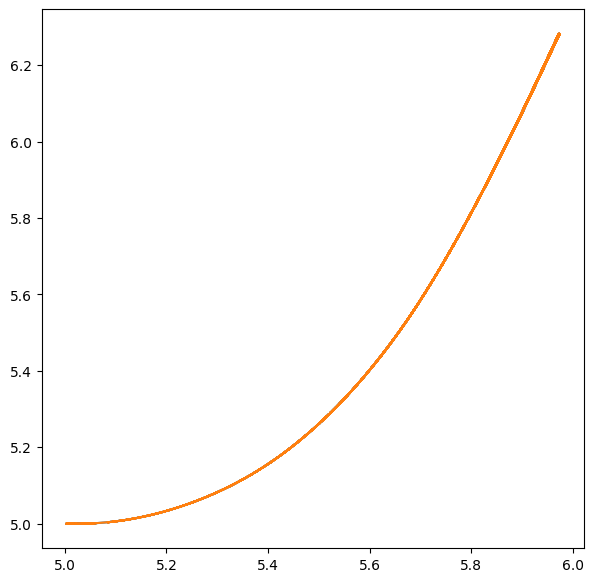

In [20]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T,kappa)

Variant number of total steps

In [21]:
steps_all=4000000

In [22]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 40000 4000000


5.881724133522114e-06


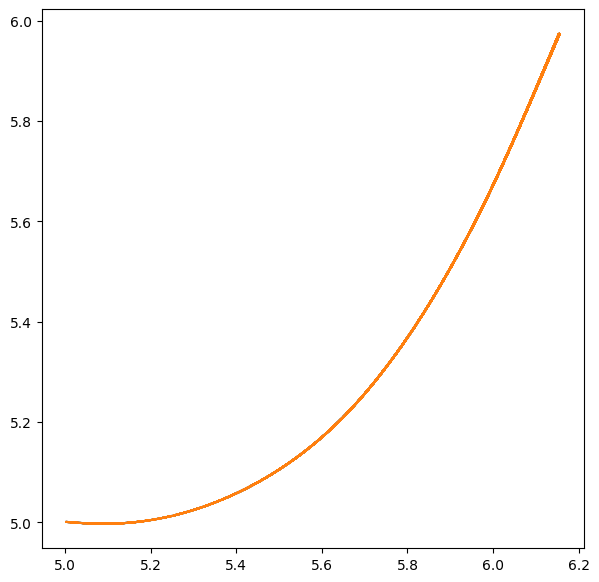

In [23]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [24]:
steps_all=4500000

In [25]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 45000 4500000


5.501712074052756e-06


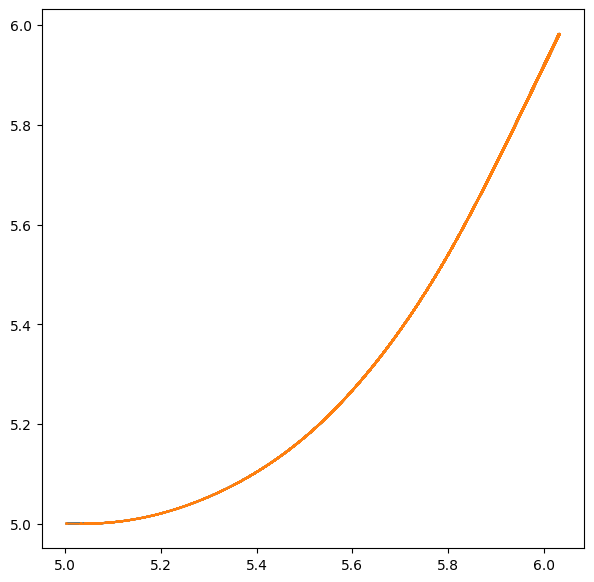

In [26]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [27]:
steps_all=5000000

In [28]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50000 5000000


4.465038561028362e-06


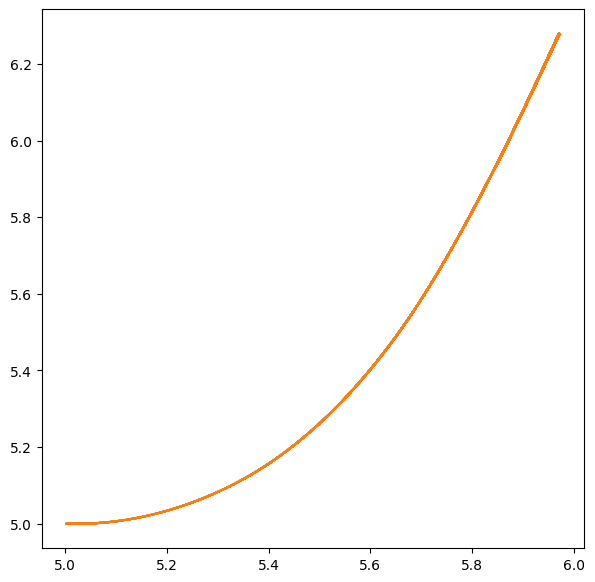

In [29]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

In [30]:
steps_all=5500000

In [31]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 55000 5500000


6.7679672270490306e-06


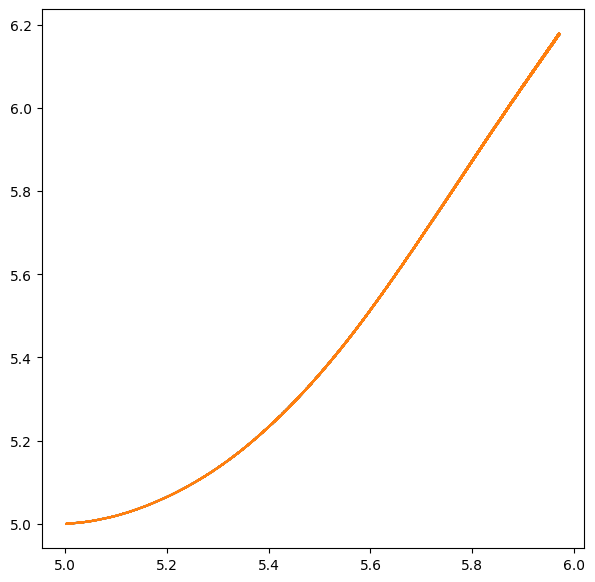

In [32]:
relative_error = accuracy_test_linear_wv(steps, blocks, steps_all,T)

Variant number of total steps with Heun

In [33]:
def accuracy_test_linear_wv_heun(steps,blocks,steps_all,T):

    kappa=200

    b_init_m=jnp.zeros_like(m0)
    A_init_m=jnp.zeros_like(P0)
    C_init_m=kappa*jnp.eye(P0.shape[0])

    steps_all=steps*blocks
    
    dt=T/steps_all
    
    X, y_discrete, _ = make_wv_data(m0, P0, F(0), L(0), H(0), steps_all, dt, q, v, t0, seed=123)
    
    est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)
    
    F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
    clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)
    
    
     
    T=clqt.T
    dt = clqt.T / steps / blocks
    ST=clqt.ST
    vT=clqt.vT
    


    S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT,diffeq_solver='heun')
    


    A_seq,b_seq,C_seq=seqFwdBwdPass(clqt,steps*blocks,dt,t0,A_init_m,b_init_m,C_init_m,diffeq_solver='heun')
    _,x_fwdbwd_seq=combine_seqFwdBwdPass(S_seq, Kx_seq, v_seq, d_seq, A_seq, b_seq, C_seq)

    Kx_par_acc, d_par_acc, S_par_acc, v_par_acc = parBackwardPass(clqt, blocks, steps, t0, dt,diffeq_solver='heun')
    u_par_fb_acc,x_par_fb_acc = parFwdBwdPass(clqt, kappa,Kx_par_acc, d_par_acc, S_par_acc, v_par_acc, blocks, steps, dt, t0,diffeq_solver='euler')

    f, (ax1) = plt.subplots(1,1, figsize=(7,7))

    ax1.plot(x_par_fb_acc[:,0], x_par_fb_acc[:,1])
    ax1.plot(x_fwdbwd_seq[:,0],x_fwdbwd_seq[:,1])

    relative_error = (
    jnp.linalg.norm(x_fwdbwd_seq - x_par_fb_acc)
    / jnp.linalg.norm(x_fwdbwd_seq)
    )

    print(relative_error)

    return relative_error

 

In [34]:
steps_all=4000000

In [35]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 40000 4000000


6.569849503192408e-05


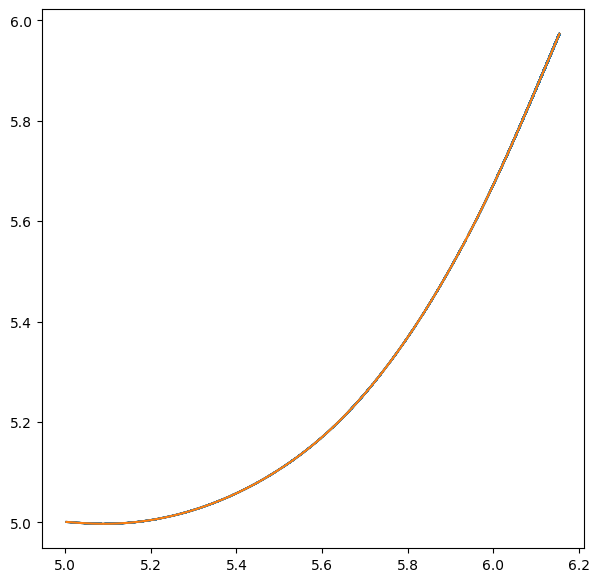

In [36]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)

In [37]:
steps_all=4500000

In [38]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 45000 4500000


3.001917265513086e-05


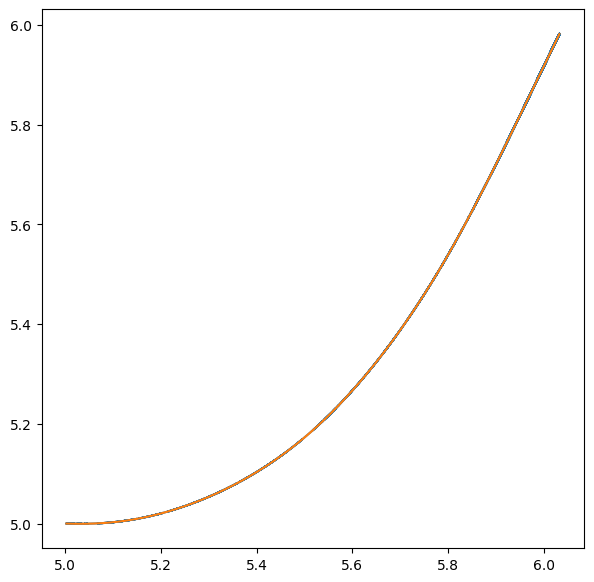

In [39]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)

In [40]:
steps_all=5000000

In [41]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50000 5000000


4.7212233465685445e-05


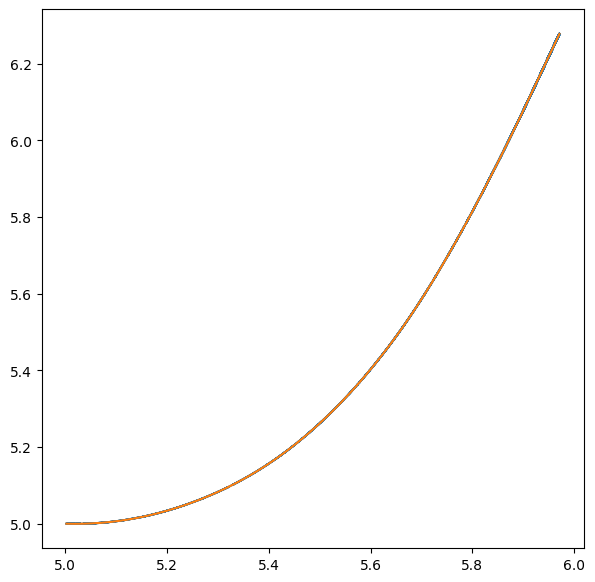

In [42]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)

In [43]:
steps_all=5500000

In [44]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 55000 5500000


3.587247334725954e-05


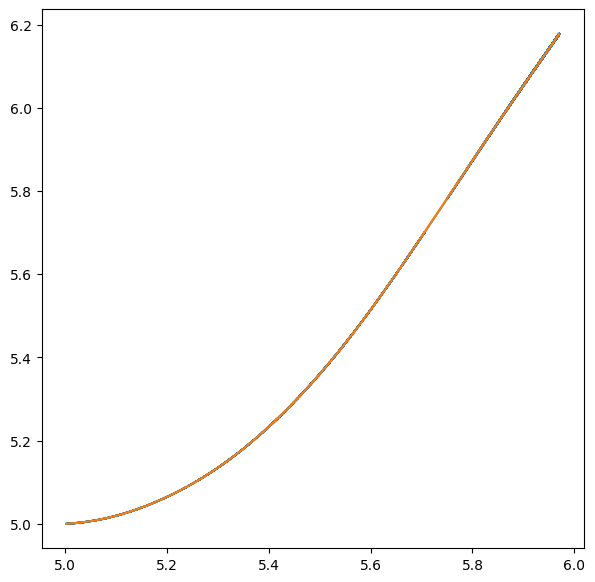

In [45]:
relative_error=accuracy_test_linear_wv_heun(steps, blocks, steps_all,T)